# One Agent -> One Tool

In [3]:
# pip install langgraph langchain-google-genai geopy requests

In [1]:
import os
from dotenv  import load_dotenv
load_dotenv()
# Read your API key from the environment variable or set it manually
api_key = os.getenv("GOOGLE_API_KEY")

In [2]:
from typing import (
    Annotated,
    Sequence,
    TypedDict,
)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    """The state of the agent."""

    messages: Annotated[Sequence[BaseMessage], add_messages]

In [2]:
from langchain_core.tools import tool

@tool
def get_weather(location: str):
    """Call to get the weather from a specific location."""
    # This is a placeholder for the actual implementation
    # Don't let the LLM know this though 😊
    if any([city in location.lower() for city in ["sf", "san francisco"]]):
        return "It's sunny in San Francisco, but you better look out if you're a Gemini 😈."
    else:
        return f"I am not sure what the weather is in {location}"

tools = [get_weather]

In [5]:
from datetime import datetime
from langchain_google_genai import ChatGoogleGenerativeAI

# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-2.0-flash",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

# Bind tools to the model
model = llm.bind_tools(tools)

# Test the model with tools # if content is None means have to call the tool
res=model.invoke(f"What is the weather in india pune?") 

print(res)

content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "india pune"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--a8ef6ac3-9b3f-47ac-8168-97b00b94507c-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'india pune'}, 'id': '1a8e7d57-9026-4c6b-9620-1b1581024d56', 'type': 'tool_call'}] usage_metadata={'input_tokens': 25, 'output_tokens': 6, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}}


In [7]:
tools_by_name = {tool.name: tool for tool in tools}
tools_by_name

{'get_weather': StructuredTool(name='get_weather', description='Call to get the weather from a specific location.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x000001E2FD2FC540>)}

In [49]:
tool_call =  {'name': 'get_weather', 'args': {'location': 'pune'}, 'id': '82cd98a0-6816-4e2c-b5ab-bc3e3d75a1cf', 'type': 'tool_call'}
tool_call["name"]

'get_weather'

In [52]:
tools_by_name

{'get_weather': StructuredTool(name='get_weather', description='Call to get the weather from a specific location.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x000001E2FD2FC540>)}

In [54]:
tool_call["args"]

{'location': 'pune'}

In [57]:
import json
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}


# Define our tool node
def tool_node(state: AgentState):
    outputs = []
    print("state", state)
    for tool_call in state["messages"][-1].tool_calls:
        print("tool_call", tool_call)
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
        print(outputs)
    return {"messages": outputs}


# Define the node that calls the model
def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # this is similar to customizing the create_react_agent with 'prompt' parameter, but is more flexible
    system_prompt = SystemMessage(
        "You are a helpful AI assistant, please respond to the users query to the best of your ability!"
    )
    response = model.invoke([system_prompt] + state["messages"], config)
    print(response, "response")
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [63]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.set_entry_point("agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    # Finally we pass in a mapping.
    # The keys are strings, and the values are other nodes.
    # END is a special node marking that the graph should finish.
    # What will happen is we will call `should_continue`, and then the output of that
    # will be matched against the keys in this mapping.
    # Based on which one it matches, that node will then be called.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("tools", "agent")


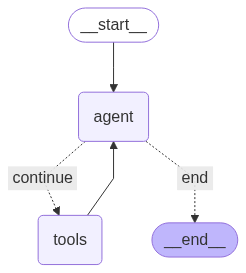

In [64]:

# Now we can compile and visualize our graph
graph = workflow.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [60]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "what is weather in pune?")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

what is weather in pune?
content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "pune"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--0f8d1b19-1bd3-41b9-82a5-99c097b750c3-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'pune'}, 'id': '812b0659-136d-4b77-9d41-4df44e082ebf', 'type': 'tool_call'}] usage_metadata={'input_tokens': 43, 'output_tokens': 6, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}} response
================================== Ai Message ==================================
Tool Calls:
  get_weather (812b0659-136d-4b77-9d41-4df44e082ebf)
 Call ID: 812b0659-136d-4b77-9d41-4df44e082ebf
  Args:
    location: pune
state {'messages': [HumanMessage(content='what is weather in pune?', additional_kwargs={}, r